# **Libraries**

In [1]:
import numpy as np
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as rfs
from sklearn.neural_network import MLPRegressor 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

from scipy.stats import uniform as sp_randFloat
from scipy.stats import randint as sp_randInt

def mape(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [2]:
data = pd.read_csv('tab_training.csv')
data_validation = pd.read_csv('tab_validation.csv')

data.head(), data_validation.head()

(   Unnamed: 0   lon   lat  year  month    prec       temp         etp
 0           1 -46.5 -23.5  1981      1  248.57  22.231935  106.048764
 1           2 -46.5 -23.5  1981      2  111.22  22.818929  101.649423
 2           3 -46.5 -23.5  1981      3  177.47  21.304839   93.651249
 3           4 -46.5 -23.5  1981      4  120.09  18.977667   67.507974
 4           5 -46.5 -23.5  1981      5   44.33  18.361613   61.594922,
    Unnamed: 0   lon   lat  year  month    prec       temp         etp
 0           1 -46.5 -23.5  2015      1  127.23  24.667742  128.816274
 1           2 -46.5 -23.5  2015      2  136.22  22.902500   98.479715
 2           3 -46.5 -23.5  2015      3  174.15  21.715806   92.170299
 3           4 -46.5 -23.5  2015      4   63.37  20.210667   71.118496
 4           5 -46.5 -23.5  2015      5   40.72  18.342903   55.356745)

# **Pre processing**

In [3]:
x1 = data[['lon','lat','year','month']]
x2 = data[['prec','temp']]
y = data['etp']

x1_vali= data_validation[['lon','lat','year','month']]
x2_validation = data_validation[['prec','temp']]
y_validation = data_validation['etp']

In [4]:
x2 = StandardScaler().fit_transform(x2)
x2 = pd.DataFrame(x2, columns=[data.columns[5:7]])
x2.head()

x2_validation = StandardScaler().fit_transform(x2_validation)
x2_validation = pd.DataFrame(x2_validation, columns=[data_validation.columns[5:7]])
x2_validation.head(),x2_validation.head()

(       prec      temp
 0  0.299911  1.924636
 1  0.416020  1.210940
 2  0.905898  0.731154
 3 -0.524860  0.122619
 4 -0.817392 -0.632527,
        prec      temp
 0  0.299911  1.924636
 1  0.416020  1.210940
 2  0.905898  0.731154
 3 -0.524860  0.122619
 4 -0.817392 -0.632527)

In [5]:
x = pd.concat([x1,x2],axis=1, join='inner')
x_validation = pd.concat([x1_vali,x2_validation],axis=1, join='inner')

x.head(),x_validation.head()

(    lon   lat  year  month   (prec,)   (temp,)
 0 -46.5 -23.5  1981      1  1.070670  1.214792
 1 -46.5 -23.5  1981      2 -0.203283  1.436720
 2 -46.5 -23.5  1981      3  0.411201  0.864278
 3 -46.5 -23.5  1981      4 -0.121012 -0.015573
 4 -46.5 -23.5  1981      5 -0.823703 -0.248488,
     lon   lat  year  month   (prec,)   (temp,)
 0 -46.5 -23.5  2015      1  0.299911  1.924636
 1 -46.5 -23.5  2015      2  0.416020  1.210940
 2 -46.5 -23.5  2015      3  0.905898  0.731154
 3 -46.5 -23.5  2015      4 -0.524860  0.122619
 4 -46.5 -23.5  2015      5 -0.817392 -0.632527)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3, random_state=1)
x_train.to_csv('x_train.csv')
y_test.to_csv('y_test.csv')
y_train.to_csv('y_train.csv')
x_test.to_csv('x_test.csv')

# **Random Forest**

In [7]:
rf_model = rfs().fit(x_train, y_train)
             

## **Random Search param**

In [8]:
n_estimators = [int(x) for x in np.linspace(start = 50, stop = 1000, num = 50)]
# Number of features to consider at every split
max_features = [1,2,3]
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(1, 100, num = 5)]

hyperpar_space = {'max_depth':max_depth,
                  'n_estimators':n_estimators,
                  'max_features':max_features
                 }

rs_rf = RandomizedSearchCV(rf_model, param_distributions=hyperpar_space,
                        n_iter=20, scoring="r2", random_state=1,
                        n_jobs=-1, cv=10, return_train_score=True).fit(x_train, y_train)

In [9]:
hyperpar_space

{'max_depth': [1, 25, 50, 75, 100],
 'n_estimators': [50,
  69,
  88,
  108,
  127,
  146,
  166,
  185,
  205,
  224,
  243,
  263,
  282,
  302,
  321,
  340,
  360,
  379,
  398,
  418,
  437,
  457,
  476,
  495,
  515,
  534,
  554,
  573,
  592,
  612,
  631,
  651,
  670,
  689,
  709,
  728,
  747,
  767,
  786,
  806,
  825,
  844,
  864,
  883,
  903,
  922,
  941,
  961,
  980,
  1000],
 'max_features': [1, 2, 3]}

In [10]:
pd.DataFrame.from_dict(rs_rf.cv_results_).to_csv('random_Forest_iter.csv')
pd.DataFrame.from_dict(rs_rf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,8.973771,0.608642,0.342499,0.064073,534,1,100,"{'n_estimators': 534, 'max_features': 1, 'max_...",0.993704,0.993756,...,0.999011,0.999081,0.999013,0.999015,0.999047,0.998999,0.998993,0.999057,0.999035,0.000031
1,6.060708,0.031641,0.198497,0.004023,398,1,50,"{'n_estimators': 398, 'max_features': 1, 'max_...",0.993425,0.993016,...,0.999018,0.999038,0.999013,0.999001,0.999038,0.998994,0.998963,0.999063,0.999009,0.000030
2,13.001706,0.554994,0.439756,0.108222,806,1,50,"{'n_estimators': 806, 'max_features': 1, 'max_...",0.993725,0.993445,...,0.999025,0.999079,0.999060,0.999050,0.999089,0.999043,0.999060,0.999060,0.999054,0.000018
3,24.871008,0.574946,0.573981,0.108961,980,3,75,"{'n_estimators': 980, 'max_features': 3, 'max_...",0.998657,0.998641,...,0.999825,0.999824,0.999824,0.999820,0.999823,0.999824,0.999827,0.999829,0.999825,0.000003
4,3.049600,0.048324,0.153851,0.010956,825,2,1,"{'n_estimators': 825, 'max_features': 2, 'max_...",0.649156,0.635703,...,0.630131,0.623761,0.625743,0.619826,0.631531,0.629118,0.613092,0.634765,0.628874,0.008402
5,6.966898,0.061549,0.179512,0.005906,360,2,100,"{'n_estimators': 360, 'max_features': 2, 'max_...",0.998232,0.998093,...,0.999740,0.999748,0.999729,0.999732,0.999734,0.999736,0.999732,0.999762,0.999739,0.000010
6,6.715046,0.063313,0.136118,0.004191,282,3,25,"{'n_estimators': 282, 'max_features': 3, 'max_...",0.998607,0.998724,...,0.999818,0.999813,0.999817,0.999815,0.999819,0.999810,0.999822,0.999828,0.999818,0.000005
7,2.666026,0.016412,0.136824,0.004688,709,2,1,"{'n_estimators': 709, 'max_features': 2, 'max_...",0.630136,0.629722,...,0.626829,0.629146,0.618321,0.630426,0.611825,0.604746,0.632432,0.622090,0.623237,0.008614
8,17.630785,0.416987,0.384088,0.009535,728,3,75,"{'n_estimators': 728, 'max_features': 3, 'max_...",0.998647,0.998712,...,0.999823,0.999829,0.999825,0.999818,0.999822,0.999821,0.999824,0.999831,0.999824,0.000003
9,2.732456,0.015972,0.136605,0.006058,728,2,1,"{'n_estimators': 728, 'max_features': 2, 'max_...",0.623728,0.627379,...,0.627206,0.624903,0.629817,0.638908,0.630485,0.631611,0.639941,0.625124,0.629519,0.005922


<AxesSubplot:>

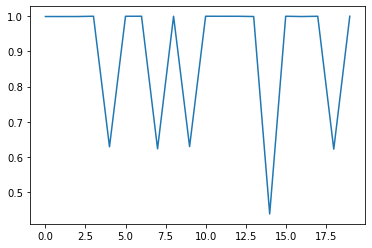

In [11]:
pd.DataFrame.from_dict(rs_rf.cv_results_)['mean_train_score'].plot()

In [12]:
print("Optimal hyperparameter combination:", rs_rf.best_params_)
print()
print("Mean cross-validated training accuracy score:",
      rs_rf.best_score_)
print()

Optimal hyperparameter combination: {'n_estimators': 728, 'max_features': 3, 'max_depth': 75}

Mean cross-validated training accuracy score: 0.9987618590104482



### ***Feature Importance***

In [13]:
importance = rs_rf.best_estimator_.feature_importances_
importance_graf = pd.DataFrame({'lon':[importance[0]],'lat':[importance[1]],
                                     'year':[importance[2]],'month':[importance[3]],
                                     'prec':[importance[4]], 'temp':[importance[5]]
                                })
importance_graf

,lon,lat,year,month,prec,temp
0,0.001988,0.007993,0.005988,0.163695,0.170994,0.649343


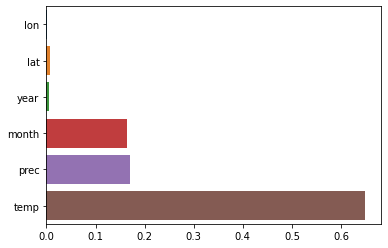

In [14]:
sns.barplot(data=importance_graf, orient='h');

## **Train**

In [15]:
yest_train = rs_rf.best_estimator_.predict(x_train)
pd.DataFrame.from_dict(yest_train).to_csv('random_Forest_train_est.csv')

In [16]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
11357,34.880442,34.877550
4772,82.118873,81.652140
7590,58.729880,60.315554
4488,99.903151,99.964208
617,33.768475,34.105878


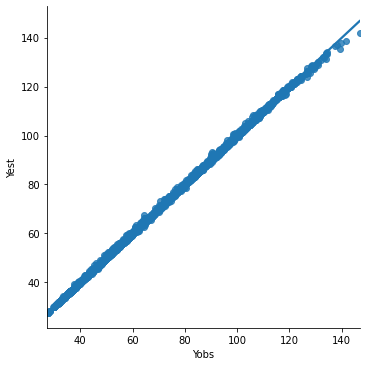

In [17]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [18]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train,yest_train)
rrmse = rmse*100/np.mean(y_train)
rf_mape = mape(y_train,yest_train)

r2,rmse,rrmse,rf_mape

(0.9998498160481543,
 0.2853958474455442,
 0.38984043754519465,
 0.19635563723312505)

findfont: Font family ['Segoe UI Bold'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Segoe UI Bold'] not found. Falling back to DejaVu Sans.


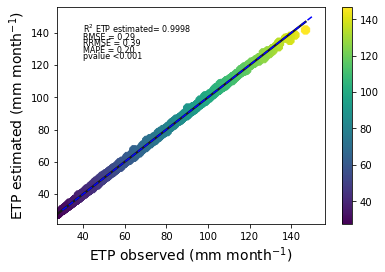

In [19]:
x=[30,150]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(40, 140, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(40,136, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,132, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,128, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(40, 124,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

#plt.savefig('.png', transparent = False,bbox_inches='tight', dpi=1000)

## **Test**

In [20]:
yest_test = rs_rf.best_estimator_.predict(x_test)
pd.DataFrame.from_dict(yest_test).to_csv('random_Forest_test_est.csv')

In [21]:
data = pd.DataFrame({'Yobs':y_test,
                         'Yest_rf': yest_test})

In [22]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
datagraf.head()

,Yobs,Yest
7135,42.857849,43.131005
2790,44.064621,44.110582
3132,94.102907,94.080255
8589,77.061335,76.865588
3841,104.288227,104.703709


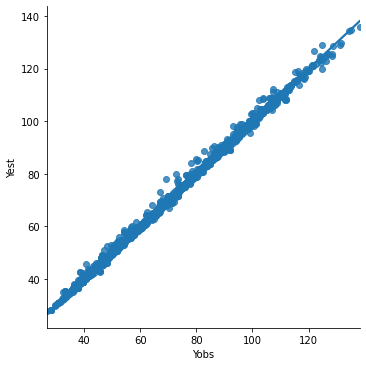

In [23]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [24]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
rf_mape = mape(y_test,yest_test)

r2,rmse,rrmse,rf_mape

(0.9989609103528272,
 0.7429731783030569,
 1.0196069360828672,
 0.5307431976527948)

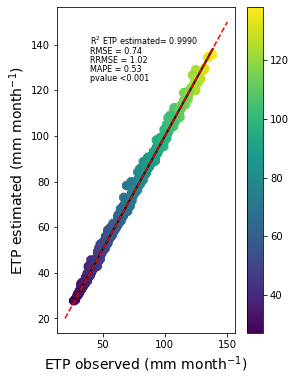

In [25]:
points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis")  #cmap é a cor da barra  
cbar = plt.colorbar(points, shrink=1)
#cbar.set_label('XCO$\mathregular{_{2}}$ estimated',fontsize=14, family='Segoe UI Bold')  #COLOCAR O NOME DA BARRA
sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

x=[20,150]
y=x

plt.plot(x,y, '--',color='red',data=None)

pvalue = 0.001
plt.text(40, 140, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(40,136, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,132, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,128, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(40, 124,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('random_forest_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **StepWise** 

In [26]:
# checando
x_train.head(), y_train.head()

(         lon    lat  year  month   (prec,)   (temp,)
 11357 -44.75 -23.00  2009      6 -0.693386 -1.688185
 4772  -45.75 -23.00  2004      9 -0.993347  0.738439
 7590  -45.25 -23.50  2001      7 -0.494432  0.341068
 4488  -45.75 -23.00  1981      1  1.528774  0.929161
 617   -46.50 -23.25  1998      6 -1.096859 -1.781318,
 11357    34.880442
 4772     82.118873
 7590     58.729880
 4488     99.903151
 617      33.768475
 Name: etp, dtype: float64)

## **Train**

In [27]:
sw_model = LinearRegression()
sfs_model = sfs(sw_model,k_features=6, forward=True, scoring='r2',cv=10)
sfs_model=sfs_model.fit(x_train, y_train)
sfs_model.k_feature_names_

('lon', 'lat', 'year', 'month', ('prec',), ('temp',))

In [28]:
table = pd.DataFrame.from_dict(sfs_model.get_metric_dict()).T
table

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
1,"(5,)","[0.9384268768784747, 0.9379317142442714, 0.937...",0.937922,"((temp,),)",0.001476,0.001987,0.000662
2,"(1, 5)","[0.9509757451720731, 0.9496528099098066, 0.948...",0.94945,"(lat, (temp,))",0.00159,0.002141,0.000714
3,"(1, 4, 5)","[0.9584302569117801, 0.9573001758793112, 0.955...",0.954812,"(lat, (prec,), (temp,))",0.004144,0.005579,0.00186
4,"(1, 2, 4, 5)","[0.9596870952327899, 0.9582565557943811, 0.956...",0.956502,"(lat, year, (prec,), (temp,))",0.003438,0.004629,0.001543
5,"(1, 2, 3, 4, 5)","[0.9610386242743058, 0.9598095681147484, 0.957...",0.957918,"(lat, year, month, (prec,), (temp,))",0.00388,0.005224,0.001741
6,"(0, 1, 2, 3, 4, 5)","[0.9626185112320852, 0.9608252397532545, 0.958...",0.958877,"(lon, lat, year, month, (prec,), (temp,))",0.003827,0.005153,0.001718


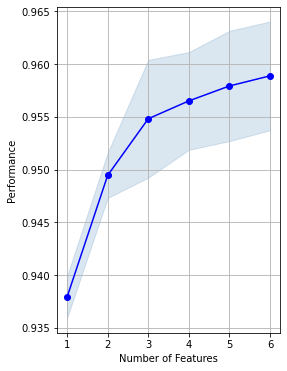

In [29]:
figure = plot_sfs(sfs_model.get_metric_dict(),kind='std_dev')
plt.grid()

In [30]:
table=table.sort_values('avg_score', ascending=False)['feature_names'].head(1)
table = table.tolist()
        
xobs_train = x_train[list(table[0][0:])]

xobs_train = sm.add_constant(xobs_train)
xobs_train.head()

C:\Users\luism\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


,const,lon,lat,year,month,"(prec,)","(temp,)"
11357,1.0,-44.75,-23.00,2009,6,-0.693386,-1.688185
4772,1.0,-45.75,-23.00,2004,9,-0.993347,0.738439
7590,1.0,-45.25,-23.50,2001,7,-0.494432,0.341068
4488,1.0,-45.75,-23.00,1981,1,1.528774,0.929161
617,1.0,-46.50,-23.25,1998,6,-1.096859,-1.781318


In [31]:
result = sm.OLS(y_train,xobs_train).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    etp   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                 3.383e+04
Date:                Wed, 14 Feb 2024   Prob (F-statistic):               0.00
Time:                        14:23:22   Log-Likelihood:                -25389.
No. Observations:                8568   AIC:                         5.079e+04
Df Residuals:                    8561   BIC:                         5.084e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        392.6006     11.775     33.341      0.000     369.518     415.683
lon           -1.6302      0.114    -14.360      0.000      -1.853      -1.408
lat            8.6352      0.182     47.462      0.000       8.279       8.992
year          -0.0984      0.005    -18.587      0.000      -0.109      -0.088
month          0.2669      0.015     17.909      0.000       0.238       0.296
('prec',)      1.9095      0.061     31.345      0.000       1.790       2.029
('temp',)     22.3644      0.063    354.286      0.000      22.241      22.488
==============================================================================
Omnibus:                      863.945   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4145.524
Skew:                          -0.382   Prob(JB):                         0.00
Kurtosis:                       6.321   Cond. No.                     4.65e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.65e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
yest_train=result.fittedvalues
pd.DataFrame.from_dict(yest_train).to_csv('sw_train_est.csv')

In [33]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
11357,34.880442,31.805323
4772,82.118873,88.425247
7590,58.729880,75.119726
4488,99.903151,97.634733
617,33.768475,30.728350


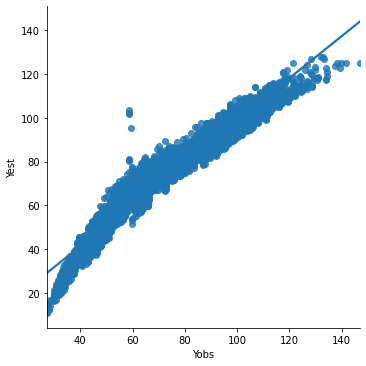

In [34]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [35]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train, yest_train)
rrmse = rmse*100/np.mean(y_train)
sw_mape = mape(y_train,yest_train)

r2,rmse,rrmse,sw_mape

(0.9595332425365527, 4.684735644456915, 6.399179980245248, 5.616963248944143)

## **Test**

In [36]:
xobs_test = x_test[list(table[0][0:])]
xobs_test = sm.add_constant(xobs_test)
yest_test = result.predict(xobs_test)

pd.DataFrame.from_dict(yest_test).to_csv('sw_test_est.csv')
yest_test.head()

C:\Users\luism\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


7135     40.294350
2790     45.097445
3132     88.021337
8589     77.598392
3841    109.319776
dtype: float64

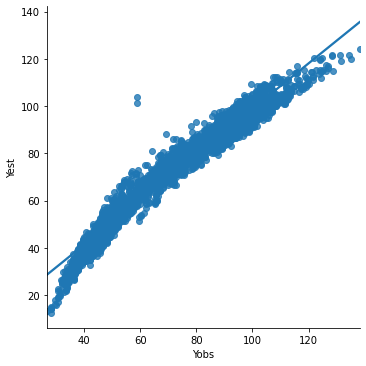

In [37]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [38]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
sw_mape = mape(y_test,yest_test)

r2,rmse,rrmse,sw_mape

(0.9600285904093304, 4.608094310041118, 6.323841906881642, 5.5460835279659495)

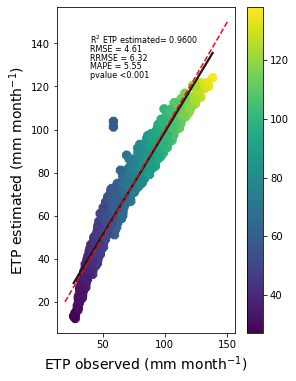

In [39]:
points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis")    
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

x=[20,150]
y=x

plt.plot(x,y, '--',color='red',data=None)

pvalue = 0.001
plt.text(40, 140, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(40,136, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,132, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,128, 'MAPE = %0.2f'% sw_mape,family='Segoe UI Bold',fontsize=8)
plt.text(40, 124,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('sw_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **MLP**

In [40]:
# checando 

x_train.head(),y_train.head()

(         lon    lat  year  month   (prec,)   (temp,)
 11357 -44.75 -23.00  2009      6 -0.693386 -1.688185
 4772  -45.75 -23.00  2004      9 -0.993347  0.738439
 7590  -45.25 -23.50  2001      7 -0.494432  0.341068
 4488  -45.75 -23.00  1981      1  1.528774  0.929161
 617   -46.50 -23.25  1998      6 -1.096859 -1.781318,
 11357    34.880442
 4772     82.118873
 7590     58.729880
 4488     99.903151
 617      33.768475
 Name: etp, dtype: float64)

In [41]:
mlp_model= MLPRegressor().fit(x_train,y_train)

## **Random Search param**

In [42]:
max_iter = [int(x) for x in np.linspace(start = 50, stop = 2050, num = 100)]
# Maximum number of levels in tree
alpha = [float(x) for x in np.arange(0.001, .3, 0.001)]
learning_rate_init = alpha


hyperpar_space_mlp = {'hidden_layer_sizes':[(5,5),(10,10),(10,5,10),(10,10,10),
                                           (50,10,50),(50,10,5),(5,10,100)],
                          'activation':['logistic','tanh','identity'],
                          'max_iter':max_iter,
                          'learning_rate_init': learning_rate_init,
                          'solver':['adam','sgd','lbfgs'],
                          'learning_rate':['constant', 'invscaling', 'adaptive'],
                          'alpha':alpha
                         }

In [43]:
rs_mlp = RandomizedSearchCV(mlp_model, param_distributions=hyperpar_space_mlp,
                        n_iter=20, scoring="r2", random_state=1,
                        n_jobs=-1, cv=10, return_train_score=True).fit(x_train,y_train)

C:\Users\luism\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: [-3.60244720e-01 -1.43949978e-03 -1.51898374e+02  9.52822683e-01
 -1.43112872e-03 -1.32255381e-03  1.91160934e-01             nan
  9.53236728e-01             nan -6.63855775e-02 -1.41872560e-03
  9.52044372e-01  9.41954497e-01 -2.45122421e-03 -1.43111138e-03
 -1.39140448e-03  9.48017043e-01  2.82249465e-01  1.53002812e-01]
  warnings.warn(
C:\Users\luism\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the train scores are non-finite: [-3.70434375e-01 -6.57359771e-08 -1.44576112e+02  9.53549974e-01
 -1.22644117e-12 -3.37792202e-05  1.92991295e-01             nan
  9.54181306e-01             nan -7.00796230e-02 -6.63531271e-04
  9.53156638e-01  9.42740945e-01 -4.25586357e-04 -1.47037937e-12
 -1.02513972e-04  9.50776564e-01  2.82099038e-01  1.53104596e-01]
  warnings.warn(
C:\Users\luism\anaconda3\li

In [44]:
print("Optimal hyperparameter combination:", rs_mlp.best_params_)
print()
print("Mean cross-validated training accuracy score:",
      rs_mlp.best_score_)

Optimal hyperparameter combination: {'solver': 'lbfgs', 'max_iter': 999, 'learning_rate_init': 0.22, 'learning_rate': 'constant', 'hidden_layer_sizes': (10, 10, 10), 'alpha': 0.28700000000000003, 'activation': 'identity'}

Mean cross-validated training accuracy score: 0.9532367284125647


In [45]:
pd.DataFrame.from_dict(rs_mlp.cv_results_).to_csv('mlp_iter.csv')
pd.DataFrame.from_dict(rs_mlp.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_solver,param_max_iter,param_learning_rate_init,param_learning_rate,param_hidden_layer_sizes,param_alpha,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,26.561343,0.776475,0.004294,0.001811,sgd,555,0.138,invscaling,"(10, 5, 10)",0.204,...,-4.076851e-07,-2.340821e-07,-4.894917e-08,-6.018031e-06,-1.324961e-08,-8.173119e-07,-1.830858e-06,-3.570272e+00,-3.704344e-01,1.067361e+00
1,6.325764,0.914768,0.006452,0.003697,sgd,1140,0.143,adaptive,"(10, 10)",0.001,...,-3.923032e-09,-1.034256e-07,-3.063806e-08,-3.667424e-08,-4.587661e-09,-1.424475e-08,-4.486563e-08,-1.082148e-07,-6.573598e-08,6.435717e-08
2,4.324600,0.352631,0.004280,0.002550,sgd,130,0.236,adaptive,"(5, 5)",0.293,...,-3.679871e-09,-8.072651e-10,-2.969829e-08,-1.445761e+03,-2.945569e-08,-2.741341e-07,-1.182420e-08,-1.818107e-06,-1.445761e+02,4.337283e+02
3,5.712016,3.486881,0.004393,0.003708,lbfgs,1322,0.038,invscaling,"(10, 5, 10)",0.092,...,9.540895e-01,9.560362e-01,9.553295e-01,9.544253e-01,9.536976e-01,9.536265e-01,9.465412e-01,9.542194e-01,9.535500e-01,2.451869e-03
4,0.612780,0.076014,0.009139,0.002506,lbfgs,433,0.266,constant,"(50, 10, 50)",0.036,...,-1.596501e-13,-1.011413e-12,-1.729727e-13,-4.156675e-13,-1.476597e-13,-8.821832e-13,-3.685940e-13,-7.707168e-13,-1.226441e-12,2.215168e-12
5,1.138278,0.243130,0.005632,0.004529,adam,938,0.086,constant,"(10, 5, 10)",0.24,...,-1.397014e-05,-5.426239e-05,-1.416824e-05,-7.682512e-05,-2.675236e-05,-2.507383e-05,-6.944153e-05,-1.830399e-06,-3.377922e-05,2.460336e-05
6,6.203623,12.742422,0.005717,0.002978,lbfgs,1706,0.092,adaptive,"(10, 10, 10)",0.211,...,1.213082e-06,-1.865041e-11,9.713971e-01,-4.330600e-10,-1.712388e-10,9.585146e-01,-4.214407e-12,-1.778822e-11,1.929913e-01,3.859930e-01
7,11.065307,0.322027,0.017562,0.007859,sgd,151,0.124,adaptive,"(50, 10, 50)",0.126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,5.792374,3.262045,0.004343,0.004563,lbfgs,999,0.22,constant,"(10, 10, 10)",0.287,...,9.542467e-01,9.560400e-01,9.553592e-01,9.537352e-01,9.536833e-01,9.533187e-01,9.540266e-01,9.539025e-01,9.541813e-01,8.127726e-04
9,7.339577,0.342304,0.010201,0.007863,sgd,130,0.286,constant,"(5, 10, 100)",0.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(-1.0, 1.0)

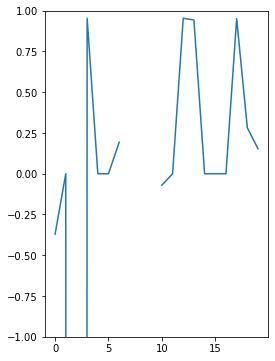

In [46]:
pd.DataFrame.from_dict(rs_mlp.cv_results_)['mean_train_score'].plot()
plt.ylim(-1,1)

## **Train**

In [47]:
yest_train = rs_mlp.best_estimator_.predict(x_train)
pd.DataFrame.from_dict(yest_train).to_csv('mlp_train_est.csv')

In [48]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
11357,34.880442,33.427227
4772,82.118873,88.712593
7590,58.729880,75.498237
4488,99.903151,95.371665
617,33.768475,32.478885


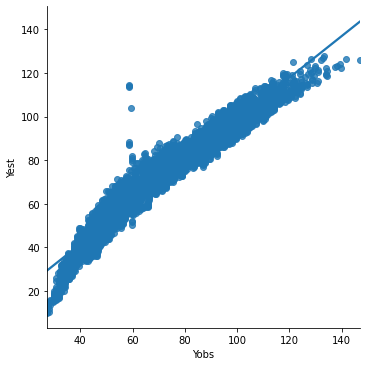

In [49]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [50]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train,yest_train)
rrmse = rmse*100/np.mean(y_train)
ann_mape = mape(y_train,yest_train)

r2,rmse,rrmse,ann_mape

(0.954293141540678, 4.978821679386151, 6.800890900564858, 5.991018872841957)

## **Test**

In [51]:
x_test.head(),y_test.head()

(        lon    lat  year  month   (prec,)   (temp,)
 7135 -45.50 -22.50  1997      8 -1.129136 -1.595784
 2790 -46.00 -23.25  2009      7 -0.044676 -1.155751
 3132 -46.00 -23.00  2004      1  0.681296  0.654628
 8589 -45.25 -22.75  1982     10  0.316130 -0.026277
 3841 -45.75 -23.50  1995      2  2.419196  1.618332,
 7135     42.857849
 2790     44.064621
 3132     94.102907
 8589     77.061335
 3841    104.288227
 Name: etp, dtype: float64)

In [52]:
yest_test = rs_mlp.best_estimator_.predict(x_test)
pd.DataFrame.from_dict(yest_test).to_csv('mlp_test_est.csv')


In [53]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
datagraf.head()

,Yobs,Yest
7135,42.857849,39.873326
2790,44.064621,48.249403
3132,94.102907,89.440779
8589,77.061335,74.612088
3841,104.288227,109.914642


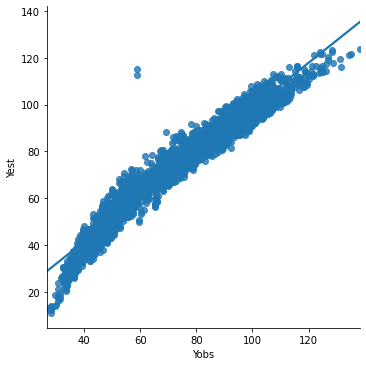

In [54]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [55]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
ann_mape = mape(y_test,yest_test)

r2,rmse,rrmse,ann_mape

(0.9549040287040312, 4.8945807698497665, 6.716996855196042, 5.88646560160422)

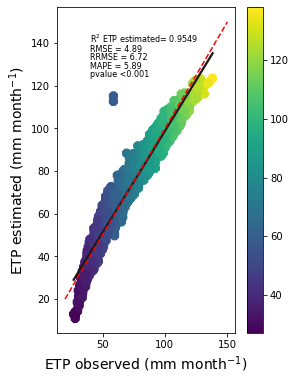

In [56]:
points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis")  
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

x=[20,150]
y=x

plt.plot(x,y, '--',color='red',data=None)

pvalue = 0.001
plt.text(40, 140, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(40,136, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,132, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,128, 'MAPE = %0.2f'% ann_mape,family='Segoe UI Bold',fontsize=8)
plt.text(40, 124,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('ann_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **General Forecasting**

In [57]:
yest_validation = rs_rf.best_estimator_.predict(x_validation)

In [58]:
datagraf = pd.DataFrame({'Yobs':y_validation,
                         'Yest': yest_validation})
datagraf.head()

,Yobs,Yest
0,128.816274,122.183810
1,98.479715,97.975404
2,92.170299,89.662982
3,71.118496,69.263065
4,55.356745,51.457654


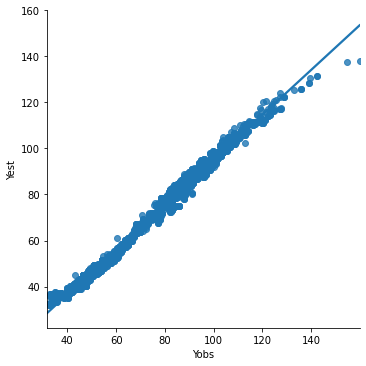

In [59]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [60]:
r2 = skm.r2_score(y_validation,yest_validation)
mse=skm.mean_squared_error(y_validation,yest_validation)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_validation, yest_validation)
rrmse = rmse*100/np.mean(y_validation)
rf_mape = mape(y_validation,yest_validation)



r2,rmse,rrmse, rf_mape

(0.9568182527733602, 4.893189326092613, 6.353839573656529, 6.121759137248932)

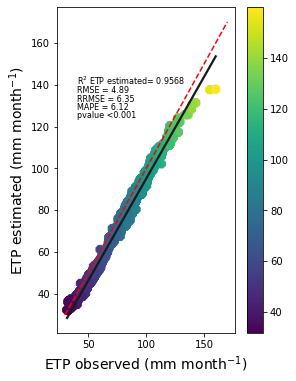

In [61]:
points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis")   
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

x=[30,170]
y=x

plt.plot(x,y, '--',color='red',data=None)


pvalue = 0.001
plt.text(40, 140, 'R$\mathregular{^{2}}$ ETP forecasted= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(40,136, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,132, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,128, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(40, 124,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP forecasted (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('rf_validation.png', transparent = False,bbox_inches='tight', dpi=1000)

In [62]:
prec = data_validation['prec']
datagraf['prec']=prec
datagraf['et_obs']=datagraf['Yobs']
datagraf['et_est']=datagraf['Yest']
datagraf['year']=data_validation['year']
datagraf['month']=data_validation['month']

datagraf.to_csv('est_validiation.csv')

# **Time series forecasting**

In [63]:
df15 = x_validation[(x_validation['year']==2015)]
df16= x_validation[(x_validation['year']==2016)]
df17= x_validation[(x_validation['year']==2017)]
df18= x_validation[(x_validation['year']==2018)]
df19= x_validation[(x_validation['year']==2019)]
df20= x_validation[(x_validation['year']==2020)]
df21= x_validation[(x_validation['year']==2021)]


In [64]:
y_15=y_validation[y_validation.index.isin(df15.index)]
y_16=y_validation[y_validation.index.isin(df16.index)]
y_17=y_validation[y_validation.index.isin(df17.index)]
y_18=y_validation[y_validation.index.isin(df18.index)]
y_19=y_validation[y_validation.index.isin(df19.index)]
y_20=y_validation[y_validation.index.isin(df20.index)]
y_21=y_validation[y_validation.index.isin(df21.index)]

In [65]:
yest_15 =rs_rf.best_estimator_.predict(df15)
datagraf = pd.DataFrame({'Yobs':y_15,
                         'Yest': yest_15})
r2 = skm.r2_score(y_15,yest_15)
mse=skm.mean_squared_error(y_15,yest_15)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_15, yest_15)
rrmse = rmse*100/np.mean(y_15)
rf_mape = mape(y_15,yest_15)



r2,rmse,rrmse, rf_mape

(0.9729136679251476, 4.077389411829336, 5.056806707089766, 4.216026745721577)

In [66]:
yest_16 =rs_rf.best_estimator_.predict(df16)
datagraf = pd.DataFrame({'Yobs':y_16,
                         'Yest': yest_16})
r2 = skm.r2_score(y_16,yest_16)
mse=skm.mean_squared_error(y_16,yest_16)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_16, yest_16)
rrmse = rmse*100/np.mean(y_16)
rf_mape = mape(y_16,yest_16)



r2,rmse,rrmse, rf_mape

(0.9501563184360431, 5.4242780545462566, 7.163693006890626, 7.303222864020735)

In [67]:
yest_17 =rs_rf.best_estimator_.predict(df17)
datagraf = pd.DataFrame({'Yobs':y_17,
                         'Yest': yest_17})
r2 = skm.r2_score(y_17,yest_17)
mse=skm.mean_squared_error(y_17,yest_17)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_17, yest_17)
rrmse = rmse*100/np.mean(y_17)
rf_mape = mape(y_17,yest_17)



r2,rmse,rrmse, rf_mape

(0.958967833535091, 4.867268054358026, 6.453208348445866, 6.371928368249086)

In [68]:
yest_18 =rs_rf.best_estimator_.predict(df18)
datagraf = pd.DataFrame({'Yobs':y_18,
                         'Yest': yest_18})
r2 = skm.r2_score(y_18,yest_18)
mse=skm.mean_squared_error(y_18,yest_18)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_18, yest_18)
rrmse = rmse*100/np.mean(y_18)
rf_mape = mape(y_18,yest_18)



r2,rmse,rrmse, rf_mape

(0.9405180598605303, 5.155394315640523, 6.822985856998414, 7.1272617732640455)

In [69]:
yest_19 =rs_rf.best_estimator_.predict(df19)

datagraf = pd.DataFrame({'Yobs':y_19,
                         'Yest': yest_19})
r2 = skm.r2_score(y_19,yest_19)
mse=skm.mean_squared_error(y_19,yest_19)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_19, yest_19)
rrmse = rmse*100/np.mean(y_19)
rf_mape = mape(y_19,yest_19)



r2,rmse,rrmse, rf_mape


(0.9699546725706578, 4.44148375978139, 5.625012297490833, 4.843991722538236)

In [70]:
yest_20 =rs_rf.best_estimator_.predict(df20)

datagraf = pd.DataFrame({'Yobs':y_20,
                         'Yest': yest_20})
r2 = skm.r2_score(y_20,yest_20)
mse=skm.mean_squared_error(y_20,yest_20)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_20, yest_20)
rrmse = rmse*100/np.mean(y_20)
rf_mape = mape(y_20,yest_20)



r2,rmse,rrmse, rf_mape

(0.952256415549355, 4.739304524016215, 6.160648828393163, 5.971403312426691)

In [71]:
yest_21 =rs_rf.best_estimator_.predict(df21)
datagraf = pd.DataFrame({'Yobs':y_21,
                         'Yest': yest_21})
r2 = skm.r2_score(y_21,yest_21)
mse=skm.mean_squared_error(y_21,yest_21)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_21, yest_21)
rrmse = rmse*100/np.mean(y_21)
rf_mape = mape(y_21,yest_21)



r2,rmse,rrmse, rf_mape

(0.9419780948642386, 5.394352733711569, 7.111062533317902, 7.018479174522114)

# **stat**

In [72]:
from scipy import stats
import numpy as np
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as rfs
from sklearn.neural_network import MLPRegressor 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [73]:
data = pd.read_csv('tab_training.csv')
data[['etp']].describe().T

,count,mean,std,min,25%,50%,75%,max
etp,12240.0,73.106439,23.218082,26.905866,51.242048,74.60097,92.767878,146.879105


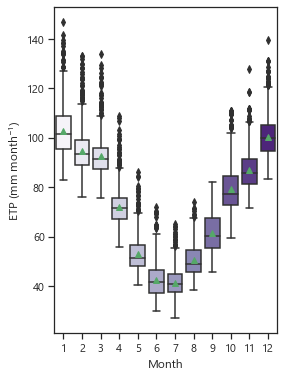

In [74]:
x = data[['etp','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Purples',data=x, x= 'month',y='etp' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('ETP (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('etpanos.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [75]:
data[['prec']].describe().T

,count,mean,std,min,25%,50%,75%,max
prec,12240.0,133.136739,107.818432,0.35,56.33,116.41,190.13,2494.39


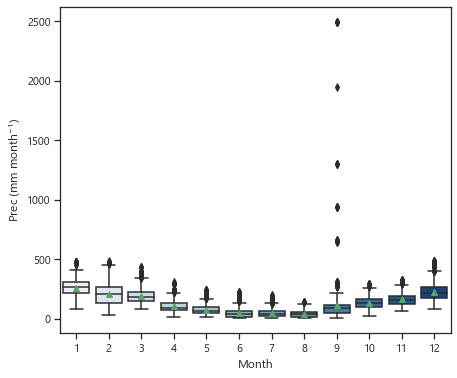

In [76]:
x = data[['prec','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Blues',data=x, x= 'month',y='prec' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('Prec (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('prec.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [77]:
data[['temp']].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,12240.0,19.018855,2.645072,11.486774,16.82629,19.454677,21.096605,26.10871


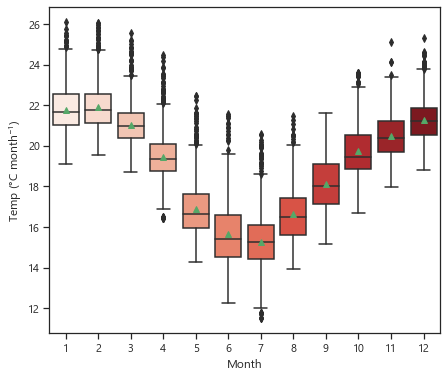

In [78]:
x = data[['temp','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Reds',data=x, x= 'month',y='temp' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('Temp (°C month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('temp.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [79]:
data.groupby('month')[['etp']].describe()

etp                                                          \
        count        mean       std        min        25%         50%   
month                                                                   
1      1020.0  102.715087  9.867621  82.959736  95.555994  101.434664   
2      1020.0   94.774302  9.047245  76.221206  88.853010   93.504597   
3      1020.0   92.447017  7.810529  75.668494  87.323792   91.582897   
4      1020.0   72.175402  7.391969  55.637645  67.024867   71.658331   
5      1020.0   53.154242  7.028248  40.477811  47.985268   51.435547   
6      1020.0   42.298597  6.750428  29.823376  37.074638   41.665908   
7      1020.0   41.154419  5.781563  26.905866  37.442781   40.934479   
8      1020.0   50.364194  6.148348  38.305700  45.613536   49.130772   
9      1020.0   61.292870  7.237928  45.891025  55.381445   60.332979   
10     1020.0   79.461597  9.670968  59.590384  72.855353   77.461591   
11     1020.0   86.983426  7.975505  71.413953  81.303723   85.913307   
12     1020.0  100.456110  8.461338  83.159429  94.776803  100.080148   

                               
              75%         max  
month                          
1      108.672645  146.879105  
2       99.161065  133.160871  
3       95.893536  133.834977  
4       75.500827  108.782610  
5       56.610305   86.244107  
6       46.685517   72.212433  
7       44.836066   65.224863  
8       54.498403   73.847266  
9       67.423836   82.118873  
10      84.641752  110.784183  
11      91.404683  127.950343  
12     105.323105  139.398381

In [80]:
data.groupby('month')[['prec']].describe()

prec                                                              \
        count        mean         std    min       25%      50%       75%   
month                                                                       
1      1020.0  260.064912   70.233688  77.70  213.5775  264.180  307.0775   
2      1020.0  203.610373   86.586764  30.39  132.1600  205.115  263.2800   
3      1020.0  190.892451   67.170784  80.00  146.7200  180.880  224.8700   
4      1020.0  101.924637   46.956902  13.73   70.2300   89.805  131.4100   
5      1020.0   75.444824   43.916512  10.56   43.2800   66.230   94.4800   
6      1020.0   48.401304   41.224443   1.19   16.0500   38.835   65.9000   
7      1020.0   49.206127   36.621014   0.35   20.7725   40.580   64.8400   
8      1020.0   38.001990   28.899772   0.38   13.8500   34.140   57.8900   
9      1020.0  113.400147  207.165837   4.94   49.5400   87.840  117.8600   
10     1020.0  129.957059   51.385102  24.10   93.6000  127.020  160.6425   
11     1020.0  160.922167   50.136774  61.88  123.4200  157.510  189.9300   
12     1020.0  225.814873   69.195362  76.09  174.5000  214.610  264.7100   

                
           max  
month           
1       476.48  
2       481.27  
3       429.56  
4       307.66  
5       237.40  
6       221.34  
7       200.76  
8       137.10  
9      2494.39  
10      291.87  
11      320.45  
12      481.66

In [81]:
data.groupby('month')[['temp']].describe()

temp                                                        \
        count       mean       std        min        25%        50%   
month                                                                 
1      1020.0  21.787635  1.151421  19.102903  21.013790  21.669677   
2      1020.0  21.939009  1.149612  19.571071  21.115357  21.774643   
3      1020.0  21.052293  1.051699  18.724516  20.384516  20.970645   
4      1020.0  19.462038  1.196224  16.455667  18.741667  19.326667   
5      1020.0  16.890501  1.374692  14.260000  15.954839  16.615484   
6      1020.0  15.630760  1.567510  12.254333  14.506000  15.408000   
7      1020.0  15.244403  1.451555  11.486774  14.403226  15.261452   
8      1020.0  16.617104  1.307217  13.908387  15.622581  16.502903   
9      1020.0  18.141795  1.261619  15.155000  17.114000  18.032333   
10     1020.0  19.734428  1.346820  16.679355  18.880645  19.454839   
11     1020.0  20.464428  1.074341  17.952333  19.708667  20.400667   
12     1020.0  21.261872  1.054015  18.802903  20.549113  21.218710   

                             
             75%        max  
month                        
1      22.533226  26.108710  
2      22.551429  26.076429  
3      21.613871  25.572581  
4      20.081083  24.466333  
5      17.606694  22.460645  
6      16.588667  21.577333  
7      16.089758  20.570000  
8      17.427419  21.482903  
9      19.115667  21.597667  
10     20.530968  23.597742  
11     21.211667  25.125000  
12     21.847419  25.310000

In [82]:
data = pd.read_csv('climatology.csv')
data

,Unnamed: 0,station,month,prec,temp,etp,etr,def,exc,wb
0,1,-46.5_-23.5,1,259.720294,22.531414,108.124307,108.124307,0.000000,151.595987,151.595987
1,2,-46.5_-23.5,2,216.072941,22.700989,99.834259,99.834259,0.000000,116.238682,116.238682
2,3,-46.5_-23.5,3,189.636765,21.698330,96.255530,96.255530,0.000000,93.381235,93.381235
3,4,-46.5_-23.5,4,114.253529,20.090490,74.768964,74.768964,0.000000,39.484565,39.484565
4,5,-46.5_-23.5,5,90.216765,17.546366,54.990811,54.990811,0.000000,35.225954,35.225954
...,...,...,...,...,...,...,...,...,...,...
355,356,-44.75_-22.5,8,32.062941,15.920095,48.357779,46.140386,2.217393,0.000000,-2.217393
356,357,-44.75_-22.5,9,84.306471,17.665696,60.146579,60.146579,0.000000,3.704297,3.704297
357,358,-44.75_-22.5,10,128.042059,19.347135,78.156459,78.156459,0.000000,49.885600,49.885600
358,359,-44.75_-22.5,11,176.969706,19.948569,84.396752,84.396752,0.000000,92.572954,92.572954


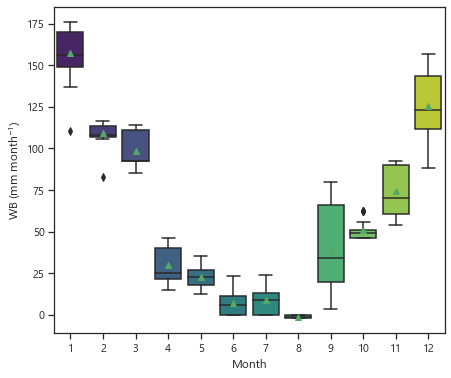

In [83]:
x = data[['wb','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='viridis',data=x, x= 'month',y='wb' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('WB (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('wdanos.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()